In [1]:
### Target: County-Level hourly MW

In [2]:
!pip install shap

In [3]:
!pip install pandas pyarrow

In [4]:
!pip install lightgbm

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns  # for nicer plots
sns.set(style="darkgrid")  # default style
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import lightgbm as lgb

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
# Read in the data
def read_file(filename):
    directory = '/content/drive/My Drive/210_capstone/final_datasets/train_rolling_windows/'
    location = directory + filename+'.parquet'
    df = pd.read_parquet(location)
    return df

In [8]:
## Read in data
df=read_file('train_window_1')
df.columns

Index(['date', 'county', 'cdd65', 'cdd65_pop', 'cdd75', 'cdd75_pop',
       'cloud_cover_pct_mean', 'cloud_cover_pct_pop', 'dpt_afternoon_k_mean',
       'dpt_afternoon_k_pop', 'dpt_morning_k_mean', 'dpt_morning_k_pop',
       'hdd65', 'hdd65_pop', 'spfh_peak_kgkg_mean', 'spfh_peak_kgkg_pop',
       'tavg_k', 'tmax_k', 'tmax_k_pop', 'tmin_k', 'tmin_k_pop', 'trange_k',
       'wind_low_ms_mean', 'wind_low_ms_pop', 'wind_peak_ms_mean',
       'wind_peak_ms_pop', 'real_data_urma', 'staying_total', 'entering_total',
       'leaving_total', 'real_data_commuting', 'cuml_count', 'cuml_sq_foot',
       'cuml_utility_cap', 'cuml_dc_load', 'real_data_data_centers',
       'electricity_usage', 'public_level_1', 'shared_private_level_1',
       'public_level_2', 'shared_private_level_2', 'public_dc_fast',
       'shared_private_dc_fast', 'total', 'real_data_ev_charging', 'bev',
       'phev', 'fcev', 'real_data_ev_poplution', 'est_median_income',
       'real_data_income', 'total_pop', 'household_

In [9]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42398 entries, 0 to 42397
Data columns (total 70 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   date                    42398 non-null  datetime64[ns]
 1   county                  42398 non-null  object        
 2   cdd65                   42398 non-null  float32       
 3   cdd65_pop               42398 non-null  float32       
 4   cdd75                   42398 non-null  float32       
 5   cdd75_pop               42398 non-null  float32       
 6   cloud_cover_pct_mean    42398 non-null  float32       
 7   cloud_cover_pct_pop     42398 non-null  float32       
 8   dpt_afternoon_k_mean    42398 non-null  float32       
 9   dpt_afternoon_k_pop     42398 non-null  float32       
 10  dpt_morning_k_mean      42398 non-null  float32       
 11  dpt_morning_k_pop       42398 non-null  float32       
 12  hdd65                   42398 non-null  float3

In [10]:
## Fix DataTypes
df['date']=pd.to_datetime(df['date'])

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42398 entries, 0 to 42397
Data columns (total 70 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   date                    42398 non-null  datetime64[ns]
 1   county                  42398 non-null  object        
 2   cdd65                   42398 non-null  float32       
 3   cdd65_pop               42398 non-null  float32       
 4   cdd75                   42398 non-null  float32       
 5   cdd75_pop               42398 non-null  float32       
 6   cloud_cover_pct_mean    42398 non-null  float32       
 7   cloud_cover_pct_pop     42398 non-null  float32       
 8   dpt_afternoon_k_mean    42398 non-null  float32       
 9   dpt_afternoon_k_pop     42398 non-null  float32       
 10  dpt_morning_k_mean      42398 non-null  float32       
 11  dpt_morning_k_pop       42398 non-null  float32       
 12  hdd65                   42398 non-null  float3

## NAN Analysis

In [12]:
# Count nulls per column
null_counts = df.isna().sum().sort_values(ascending=False)

# Show only columns with nulls
null_counts[null_counts > 0]


,0
holiday,41180
shared_private_level_2,26448
real_data_ev_charging,26448
total,26448
public_level_1,26448
public_level_2,26448
public_dc_fast,26448
shared_private_dc_fast,26448
shared_private_level_1,26448


In [13]:
null_percent = (df.isna().mean() * 100).sort_values(ascending=False)

null_percent[null_percent > 0]


,0
holiday,97.127223
shared_private_level_2,62.380301
real_data_ev_charging,62.380301
total,62.380301
public_level_1,62.380301
public_level_2,62.380301
public_dc_fast,62.380301
shared_private_dc_fast,62.380301
shared_private_level_1,62.380301


In [14]:
df[df["date"].isna()].head(10)


,date,county,cdd65,cdd65_pop,cdd75,cdd75_pop,cloud_cover_pct_mean,cloud_cover_pct_pop,dpt_afternoon_k_mean,dpt_afternoon_k_pop,...,occupied,real_data_population,area,year,month,day_of_year,day_of_week,quarter,holiday,is_holiday


In [15]:
null_counts = (df.groupby("county")["electricity_usage"].apply(lambda x: x.isna().sum()).sort_values(ascending=False))

null_counts[null_counts > 0].sort_values(ascending=False)


,electricity_usage
county,


## Feature Store

In [16]:
selected_features = [

    # =========================
    # CATEGORICAL / IDENTIFIERS
    # =========================
    "county",
    #"area",

    # =========================
    # CALENDAR / TIME
    # =========================
    #"year",
    "quarter",
    "month",
    #"day_of_year",
    "day_of_week",
    #"holiday",
    "is_holiday",

    # =========================
    # TEMPERATURE
    # =========================
    #"tavg_k",
    #"tmin_k",
    "tmin_k_pop",
    #"tmax_k",
    "tmax_k_pop",
    #"trange_k",

    # =========================
    # DEGREE DAYS
    # =========================
    #"hdd65",
    "hdd65_pop",
    #"cdd65",
    "cdd65_pop",
    #"cdd75",
    "cdd75_pop",
    "cdd65_pop_roll5",
    "hdd65_pop_roll5",
    "tmax_k_pop_roll5_max",
    # "tmax_k_pop_roll3_mean",
    "tmax_k_pop_roll7_mean",
    # "tmax_k_pop_roll3_max",
    # "tmax_k_pop_roll7_max",

    # =========================
    # DEWPOINT
    # =========================
    #"dpt_afternoon_k_mean",
    "dpt_afternoon_k_pop",
    # "dpt_morning_k_mean",
    # "dpt_morning_k_pop",

    # =========================
    # SPECIFIC HUMIDITY
    # =========================
    #"spfh_peak_kgkg_mean",
    "spfh_peak_kgkg_pop",

    # =========================
    # CLOUD COVER
    # =========================
   # "cloud_cover_pct_mean",
    "cloud_cover_pct_pop",

    # =========================
    # WIND
    # =========================
    #"wind_low_ms_mean",
    #"wind_low_ms_pop",
    #"wind_peak_ms_mean",
    "wind_peak_ms_pop",

    # =========================
    # MOBILITY / COMMUTING
    # =========================
    "staying_total",
    "entering_total",
    "leaving_total",

    # =========================
    # DATA CENTERS
    # =========================
    "cuml_count",
    "cuml_sq_foot",
    "cuml_utility_cap",
    "cuml_dc_load",

    # =========================
    # EV CHARGING INFRASTRUCTURE
    # =========================
    # "public_level_1",
    # "shared_private_level_1",
    # "public_level_2",
    # "shared_private_level_2",
    # "public_dc_fast",
    # "shared_private_dc_fast",
    # "total",

    # =========================
    # EV POPULATION
    # =========================
    "bev",
    "phev",
    "fcev",

    # =========================
    # INCOME
    # =========================
    "est_median_income",

    # =========================
    # DEMOGRAPHICS / HOUSING
    # =========================
    "total_pop",
    # "household_pop",
    # "group_quarters_pop",
    # "total_households",
    # "single_detached",
    # "single_attached",
    # "two_to_four",
    # "five_plus",
    # "mobile_homes",
    # "occupied",

    # =========================
    # DATA QUALITY FLAGS
    # =========================
    # "real_data_urma",
    # "real_data_commuting",
    # "real_data_data_centers",
    # "real_data_ev_charging",
    # "real_data_ev_poplution",
    # "real_data_income",
    # "real_data_population",

     # --- Base temperature transforms ---
    # "tmax_f",
    # "hot_85",
    "very_hot_95",
    # "pop_x_tmax_f",
    # "hot_85_pop",
    # "very_hot_95_pop",

    # --- Optional categorical bin ---
    # "tmax_bin",

    # --- Rolling hot-day counts ---
    # "hot_85_roll7",
    #"very_hot_95_roll7",
    # "hot_85_roll14",
    "very_hot_95_roll14",

    # --- Rolling pop-weighted hot-day counts ---
    # "hot_85_pop_roll7",
    "very_hot_95_pop_roll7",

    # --- Rolling temperature stats (°F) ---
    "tmax_f_roll3_mean",
    "tmax_f_roll7_mean",
    "tmax_f_roll3_max",
    "tmax_f_roll7_max",
]

## Identify Target, Categorical and Cols on full dataset

In [17]:
## Setting up Target / Data Types

target = "electricity_usage"
cat_cols=["county","day_of_week"]

## Light GBM Categorical Variables

## Feature Engineering

In [18]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

In [19]:
def run_window(train_df, val_df, selected_features, params):

    X_train = train_df[selected_features]
    y_train = train_df[target]
    X_val   = val_df[selected_features]
    y_val   = val_df[target]

    # Track metrics
    evals_result = {}

    model = lgb.LGBMRegressor(**params)

    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        eval_metric="rmse",
        callbacks=[
            lgb.log_evaluation(period=50),
            lgb.early_stopping(300, verbose=False),
            lgb.record_evaluation(evals_result)
        ]
    )

    preds = model.predict(X_val, num_iteration=model.best_iteration_)
    score = rmse(y_val, preds)

    return model, score, model.best_iteration_

params = dict(
    n_estimators=3000,
    learning_rate=0.01,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    min_data_in_leaf=100,
    reg_lambda=1.0,
)

In [ ]:
train_1 = read_file('train_window_1')
train_2 = read_file('train_window_2')
val_1 = read_file('val_window_1')
val_2 = read_file('val_window_2')

print("train_1:", train_1.shape)
print("train_2:", train_2.shape)
print("val_1:", val_1.shape)
print("val_2:", val_2.shape)


In [24]:
POP_COL = "total_pop"

datasets = {"train_1": train_1, "train_2": train_2, "val_1": val_1, "val_2": val_2}

for name, d in datasets.items():
    d2 = add_temp_threshold_features(d, tmax_k_col="tmax_k", pop_col=POP_COL, make_bins=False)
    d2 = add_rolling_features(d2, strict=True)  # strict=True is fine once pop_col is correct
    datasets[name] = d2
    print(name, "-> has very_hot_95_pop_roll7:", "very_hot_95_pop_roll7" in d2.columns)

train_1, train_2, val_1, val_2 = datasets["train_1"], datasets["train_2"], datasets["val_1"], datasets["val_2"]


train_1 -> has very_hot_95_pop_roll7: True
train_2 -> has very_hot_95_pop_roll7: True
val_1 -> has very_hot_95_pop_roll7: True
val_2 -> has very_hot_95_pop_roll7: True


In [42]:
import numpy as np
import pandas as pd

def add_temp_threshold_features(df,
                                tmax_k_col="tmax_k",
                                pop_col="population",
                                make_bins=False):
    """
    Adds temp-in-F, hot-day flags, and optional bins.
    Also adds pop-weighted versions if pop_col exists.

    Assumes df has:
      - tmax_k_col (Kelvin)
      - optionally pop_col
    """
    df = df.copy()

    if tmax_k_col not in df.columns:
        raise KeyError(f"Missing '{tmax_k_col}' needed for temp threshold features")

    # Kelvin -> Fahrenheit
    df["tmax_f"] = (df[tmax_k_col] - 273.15) * 9/5 + 32

    # Threshold flags (these are often very predictive)
    df["hot_85"] = (df["tmax_f"] >= 85).astype(np.int8)
    df["very_hot_95"] = (df["tmax_f"] >= 95).astype(np.int8)

    # Optional bins (categorical; LightGBM can handle category dtype)
    if make_bins:
        bins = [-50, 40, 55, 65, 75, 85, 95, 120]
        labels = ["<40", "40-55", "55-65", "65-75", "75-85", "85-95", "95+"]
        df["tmax_bin"] = pd.cut(df["tmax_f"], bins=bins, labels=labels, include_lowest=True)
        df["tmax_bin"] = df["tmax_bin"].astype("category")

    # Pop interactions (if you want them; you already do pop-weighted in other cols)
    if pop_col in df.columns:
        df["hot_85_pop"] = df["hot_85"] * df[pop_col]
        df["very_hot_95_pop"] = df["very_hot_95"] * df[pop_col]
        # also sometimes useful:
        df["pop_x_tmax_f"] = df[pop_col] * df["tmax_f"]

    return df


# --- rolling feature specs ---
ROLLING_SPECS = [
    # existing
    ("cdd65_pop_roll5",       "cdd65_pop",  5, "sum"),
    ("hdd65_pop_roll5",       "hdd65_pop",  5, "sum"),
    ("tmax_k_pop_roll5_max",  "tmax_k_pop", 5, "max"),
    ("tmax_k_pop_roll3_mean", "tmax_k_pop", 3, "mean"),
    ("tmax_k_pop_roll7_mean", "tmax_k_pop", 7, "mean"),
    ("tmax_k_pop_roll3_max",  "tmax_k_pop", 3, "max"),
    ("tmax_k_pop_roll7_max",  "tmax_k_pop", 7, "max"),

    # NEW: temp threshold rollups (counts of hot days)
    ("hot_85_roll7",          "hot_85",        7, "sum"),
    ("very_hot_95_roll7",     "very_hot_95",   7, "sum"),
    ("hot_85_roll14",         "hot_85",       14, "sum"),
    ("very_hot_95_roll14",    "very_hot_95",  14, "sum"),

    # NEW: if you made pop-weighted flags
    ("hot_85_pop_roll7",      "hot_85_pop",     7, "sum"),
    ("very_hot_95_pop_roll7", "very_hot_95_pop",7, "sum"),

    # Optional: rolling max/mean of temp in F (sometimes nicer than K)
    ("tmax_f_roll3_mean",     "tmax_f",         3, "mean"),
    ("tmax_f_roll7_mean",     "tmax_f",         7, "mean"),
    ("tmax_f_roll3_max",      "tmax_f",         3, "max"),
    ("tmax_f_roll7_max",      "tmax_f",         7, "max"),
]

def add_rolling_features(df, strict=False):
    df = df.sort_values(["county", "date"]).copy()
    g = df.groupby("county", sort=False)

    missing = []
    for new_col, src_col, window, agg in ROLLING_SPECS:
        if src_col not in df.columns:
            missing.append((new_col, src_col))
            if strict:
                raise KeyError(f"Missing source column '{src_col}' needed for '{new_col}'")
            continue

        df[new_col] = g[src_col].transform(
            lambda x, w=window, a=agg: getattr(x.rolling(w, min_periods=1), a)()
        )

    if missing and not strict:
        print("⚠️ Skipped rolling features due to missing source cols:")
        for new_col, src_col in missing:
            print(f"  - {new_col} (needs {src_col})")

    return df


# --- apply to all your datasets ---
datasets = {
    "train_1": train_1,
    "train_2": train_2,
    "val_1": val_1,
    "val_2": val_2,
}

for name, d in datasets.items():
    # 1) add temp threshold features first
    #    (set tmax_k_col to whatever you actually have: "t2m_max_k" vs "tmax_k")
    d2 = add_temp_threshold_features(d, tmax_k_col="tmax_k", pop_col="population", make_bins=False)

    # 2) then rolling features
    d2 = add_rolling_features(d2)

    datasets[name] = d2
    print(f"{name}: added temp+rolling cols -> shape={datasets[name].shape}")

# overwrite your variables (optional convenience)
train_1 = datasets["train_1"]
train_2 = datasets["train_2"]
val_1   = datasets["val_1"]
val_2   = datasets["val_2"]


/tmp/ipython-input-2924242220.py:75: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = df.groupby("county", sort=False)
/tmp/ipython-input-2924242220.py:75: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = df.groupby("county", sort=False)


train_1: added temp+rolling cols -> shape=(42398, 93)
train_2: added temp+rolling cols -> shape=(42398, 93)
val_1: added temp+rolling cols -> shape=(21170, 93)


/tmp/ipython-input-2924242220.py:75: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = df.groupby("county", sort=False)
/tmp/ipython-input-2924242220.py:75: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = df.groupby("county", sort=False)


val_2: added temp+rolling cols -> shape=(21170, 93)


In [43]:
cat_cols = ["county", "day_of_week"]

def set_and_align_categories(train_df, val_df, cat_cols=cat_cols):
    for c in cat_cols:
        if c in train_df.columns and c in val_df.columns:
            train_df[c] = train_df[c].astype("category")
            val_df[c]   = val_df[c].astype("category")
            # align val categories to train categories
            val_df[c] = val_df[c].cat.set_categories(train_df[c].cat.categories)
    return train_df, val_df


In [44]:
selected_features = [
    f for f in selected_features
    if f in train_1.columns and f in val_1.columns
]

In [45]:
train_1, val_1 = set_and_align_categories(train_1, val_1)
train_2, val_2 = set_and_align_categories(train_2, val_2)


In [46]:
model1, rmse1, it1 = run_window(train_1, val_1, selected_features, params)
model2, rmse2, it2 = run_window(train_2, val_2, selected_features, params)

avg_rmse = (rmse1 + rmse2) / 2
print(
    f"""
rmse_window_1: {rmse1:.2f}
rmse_window_2: {rmse2:.2f}
avg_rmse:      {avg_rmse:.2f}
best_iters:    ({it1}, {it2})
"""
)

[LightGBM] [Warning] min_data_in_leaf is set=100, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=100
[LightGBM] [Warning] min_data_in_leaf is set=100, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=100
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005706 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7754
[LightGBM] [Info] Number of data points in the train set: 42398, number of used features: 37
[LightGBM] [Warning] min_data_in_leaf is set=100, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=100
[LightGBM] [Info] Start training from score 12999.628873
[50]	valid_0's rmse: 18066.1	valid_0's l2: 3.26384e+08
[100]	valid_0's rmse: 12059.1	valid_0's l2: 1.45422e+08
[150]	valid_0's rmse: 8774.27	valid_0's l2: 7.69877e+07
[200]	valid_0's rmse: 6912.57	valid_0's l2: 4.77836

In [29]:
for name, d in {"train_1": train_1, "val_1": val_1}.items():
    print("\n", name)
    print("pop-ish cols:", [c for c in d.columns if "pop" in c.lower()][:30])
    print("has tmax_k?", "tmax_k" in d.columns)



 train_1
pop-ish cols: ['cdd65_pop', 'cdd75_pop', 'cloud_cover_pct_pop', 'dpt_afternoon_k_pop', 'dpt_morning_k_pop', 'hdd65_pop', 'spfh_peak_kgkg_pop', 'tmax_k_pop', 'tmin_k_pop', 'wind_low_ms_pop', 'wind_peak_ms_pop', 'real_data_ev_poplution', 'total_pop', 'household_pop', 'group_quarters_pop', 'real_data_population', 'cdd65_pop_roll5', 'hdd65_pop_roll5', 'tmax_k_pop_roll5_max', 'tmax_k_pop_roll3_mean', 'tmax_k_pop_roll7_mean', 'tmax_k_pop_roll3_max', 'tmax_k_pop_roll7_max', 'hot_85_pop', 'very_hot_95_pop', 'pop_x_tmax_f', 'hot_85_pop_roll7', 'very_hot_95_pop_roll7']
has tmax_k? True

 val_1
pop-ish cols: ['cdd65_pop', 'cdd75_pop', 'cloud_cover_pct_pop', 'dpt_afternoon_k_pop', 'dpt_morning_k_pop', 'hdd65_pop', 'spfh_peak_kgkg_pop', 'tmax_k_pop', 'tmin_k_pop', 'wind_low_ms_pop', 'wind_peak_ms_pop', 'real_data_ev_poplution', 'total_pop', 'household_pop', 'group_quarters_pop', 'real_data_population', 'cdd65_pop_roll5', 'hdd65_pop_roll5', 'tmax_k_pop_roll5_max', 'tmax_k_pop_roll3_mean', 

In [40]:
mean_load = df["electricity_usage"].mean()

rmse_pct = 100 * avg_rmse / mean_load
w1_rmse_pct = 100 * rmse1 / mean_load
w2_rmse_pct = 100 * rmse2 / mean_load


print(f"Mean load: {mean_load:,.2f}")
print(f"Avg RMSE:  {avg_rmse:,.2f}")
print(f"RMSE as % of mean load: {rmse_pct:.2f}%")
print(f"RMSE 1 % mean load: {w1_rmse_pct:.2f}%")
print(f"RMSE 2 % mean load: {w2_rmse_pct:.2f}%")

Mean load: 12,999.63
Avg RMSE:  5,485.63
RMSE as % of mean load: 42.20%
RMSE 1 % mean load: 36.72%
RMSE 2 % mean load: 47.68%


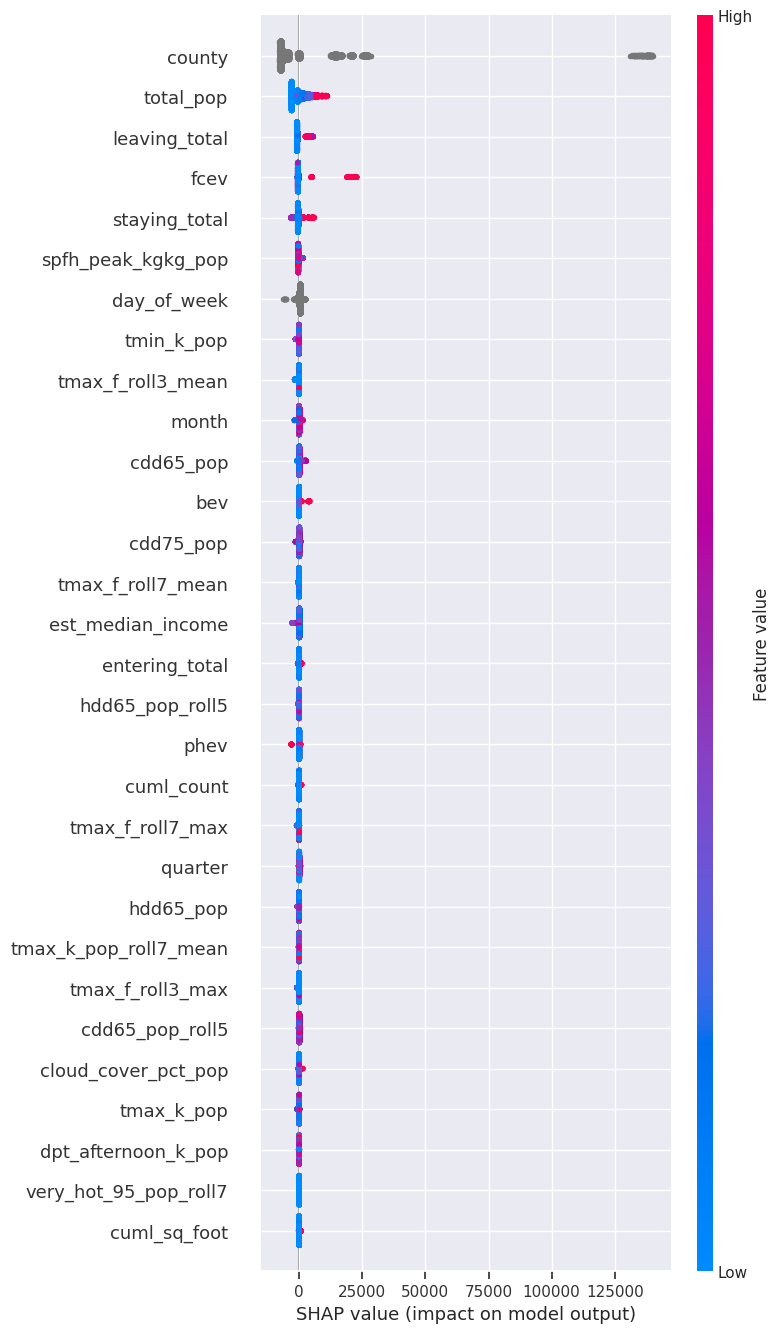

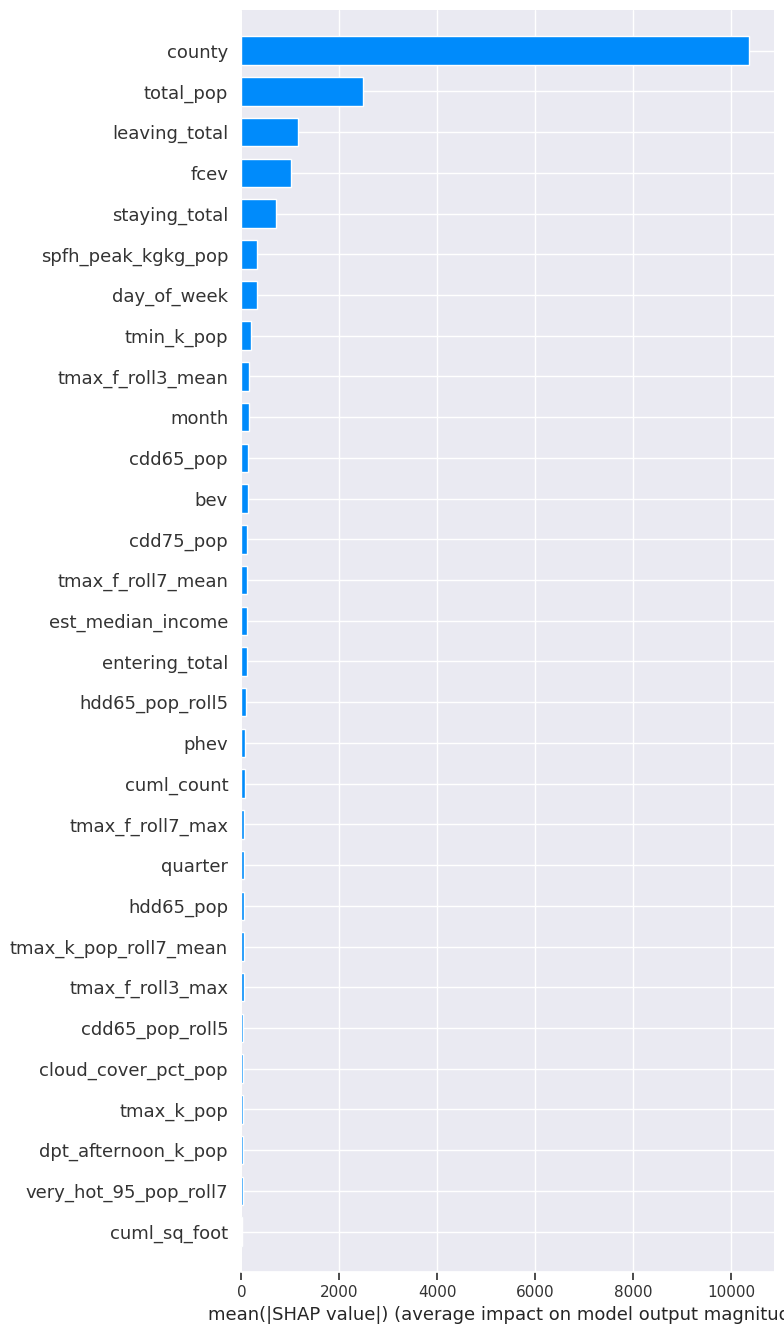

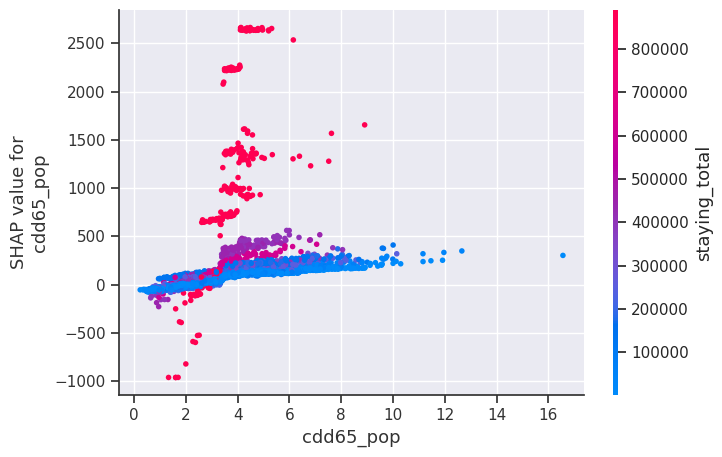

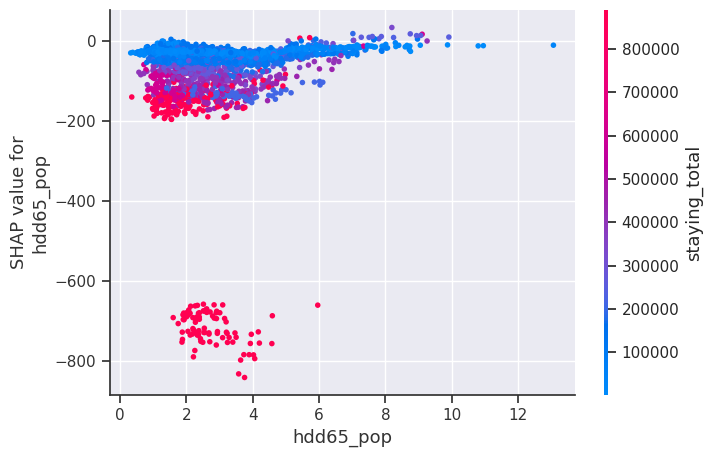

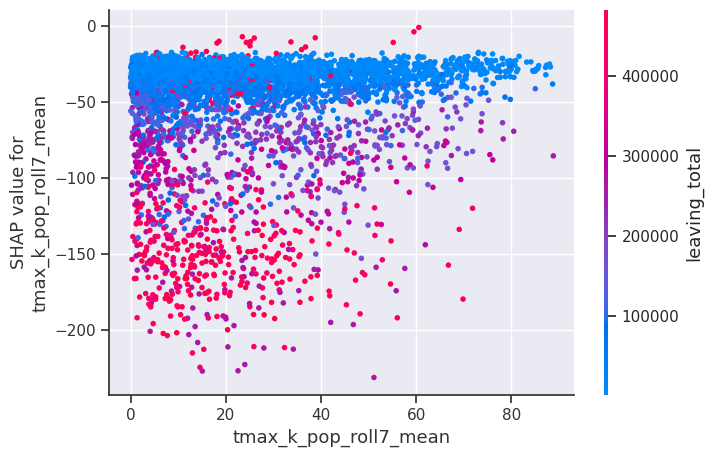

In [30]:
# =========================
# SHAP EXPLAINABILITY BLOCK
# =========================

import shap
import numpy as np

# Make sure we're using the same feature matrix used for prediction
X_val = val_1[selected_features].copy()

# Optional: ensure county is categorical (only if you trained it that way)
if "county" in X_val.columns:
    X_val["county"] = X_val["county"].astype("category")

# Sample for speed (adjust n if needed)
X_shap = X_val.sample(n=min(5000, len(X_val)), random_state=42)

# Create SHAP explainer
explainer = shap.TreeExplainer(model1)

# Compute SHAP values
shap_values = explainer.shap_values(X_shap)

# =========================
# GLOBAL FEATURE IMPORTANCE
# =========================

shap.summary_plot(shap_values, X_shap, max_display=30)
shap.summary_plot(shap_values, X_shap, plot_type="bar", max_display=30)

# =========================
# DEPENDENCE PLOTS (KEY FEATURES)
# =========================

for f in [
    "cdd65_pop",
    "hdd65_pop",
    "tmax_k_pop_roll7_mean",
    "very_hot_95_roll7"
]:
    if f in X_shap.columns:
        shap.dependence_plot(f, shap_values, X_shap)


In [41]:
std_load = df["electricity_usage"].std()
print("Std load:", std_load)
print("RMSE / std:", avg_rmse / std_load)
print("RMSE1 / std:", rmse1 / std_load)
print("RMSE2 / std:", rmse2 / std_load)

Std load: 28213.739490743283
RMSE / std: 0.19443125090892543
RMSE1 / std: 0.16917273579865963
RMSE2 / std: 0.2196897660191912


In [33]:
def weighted_rmse(y_true, y_pred, weights):
    return np.sqrt(np.sum(weights * (y_true - y_pred) ** 2) / np.sum(weights))


In [34]:
import numpy as np

def weighted_rmse(y_true, y_pred, weights):
    weights = np.asarray(weights)
    return np.sqrt(np.sum(weights * (y_true - y_pred) ** 2) / np.sum(weights))

preds1 = model1.predict(
    val_1[selected_features],
    num_iteration=model1.best_iteration_
)

w_rmse1 = weighted_rmse(
    val_1["electricity_usage"].values,
    preds1,
    val_1["total_pop"].values
)

print("Population-weighted RMSE (window 1):", w_rmse1)


[LightGBM] [Warning] min_data_in_leaf is set=100, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=100
Population-weighted RMSE (window 1): 15605.81397306425


In [35]:
preds2 = model2.predict(
    val_2[selected_features],
    num_iteration=model2.best_iteration_
)

w_rmse2 = weighted_rmse(
    val_2["electricity_usage"].values,
    preds2,
    val_2["total_pop"].values
)

print("Population-weighted RMSE (window 2):", w_rmse2)
print("Avg population-weighted RMSE:", (w_rmse1 + w_rmse2)/2)


[LightGBM] [Warning] min_data_in_leaf is set=100, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=100
Population-weighted RMSE (window 2): 17534.779080369462
Avg population-weighted RMSE: 16570.296526716855


In [36]:
w_mean_load_1 = np.average(val_1["electricity_usage"].values, weights=val_1["total_pop"].values)
print("Pop-weighted mean load (w1):", w_mean_load_1)
print("Pop-weighted RMSE % (w1):", 100 * w_rmse1 / w_mean_load_1)


Pop-weighted mean load (w1): 71842.76339836429
Pop-weighted RMSE % (w1): 21.722179430280047


In [37]:
plt.figure(figsize=(10,6))

plt.plot(evals_result["training"]["rmse"], label="Train RMSE")
plt.plot(evals_result["valid_1"]["rmse"], label="Validation RMSE")

plt.xlabel("Iteration")
plt.ylabel("RMSE")
plt.title("Training vs Validation RMSE per Boosting Iteration")
plt.legend()
plt.show()


NameError: name 'evals_result' is not defined

<Figure size 1000x600 with 0 Axes>

## OLD Split into Test/Train/Val

In [ ]:
## Rolling Window Cols

# Sort first (critical)
df = df.sort_values(["county", "date"])

df["cdd65_pop_roll5"] = (
    df.groupby("county")["cdd65_pop"]
      .transform(lambda x: x.rolling(5, min_periods=1).sum())
)

df["hdd65_pop_roll5"] = (
    df.groupby("county")["hdd65_pop"]
      .transform(lambda x: x.rolling(5, min_periods=1).sum())
)

df["tmax_k_pop_roll5_max"] = (
    df.groupby("county")["tmax_k_pop"]
      .transform(lambda x: x.rolling(window=5, min_periods=1).max())
)

df["tmax_k_pop_roll3_mean"] = (
    df.groupby("county")["tmax_k_pop"]
      .transform(lambda x: x.rolling(window=3, min_periods=1).mean())
)

df["tmax_k_pop_roll7_mean"] = (
    df.groupby("county")["tmax_k_pop"]
      .transform(lambda x: x.rolling(window=7, min_periods=1).mean())
)

df["tmax_k_pop_roll3_max"] = (
    df.groupby("county")["tmax_k_pop"]
      .transform(lambda x: x.rolling(3, min_periods=1).max())
)

df["tmax_k_pop_roll7_max"] = (
    df.groupby("county")["tmax_k_pop"]
      .transform(lambda x: x.rolling(7, min_periods=1).max())
)

In [ ]:
# # --- rolling feature specs ---
# ROLLING_SPECS = [
#     # (new_col, source_col, window, agg)
#     ("cdd65_pop_roll5",       "cdd65_pop",  5, "sum"),
#     ("hdd65_pop_roll5",       "hdd65_pop",  5, "sum"),
#     ("tmax_k_pop_roll5_max",  "tmax_k_pop", 5, "max"),
#     ("tmax_k_pop_roll3_mean", "tmax_k_pop", 3, "mean"),
#     ("tmax_k_pop_roll7_mean", "tmax_k_pop", 7, "mean"),
#     ("tmax_k_pop_roll3_max",  "tmax_k_pop", 3, "max"),
#     ("tmax_k_pop_roll7_max",  "tmax_k_pop", 7, "max"),
# ]

# def add_rolling_features(df):
#     df = df.sort_values(["county", "date"]).copy()
#     g = df.groupby("county", sort=False)

#     for new_col, src_col, window, agg in ROLLING_SPECS:
#         if src_col not in df.columns:
#             raise KeyError(f"Missing source column '{src_col}' needed for '{new_col}'")

#         df[new_col] = g[src_col].transform(
#             lambda x, w=window, a=agg: getattr(x.rolling(w, min_periods=1), a)()
#         )
#     return df

# # --- apply to all your datasets ---
# datasets = {
#     "train_1": train_1,
#     "train_2": train_2,
#     "val_1": val_1,
#     "val_2": val_2,
# }

# for name, d in datasets.items():
#     datasets[name] = add_rolling_features(d)
#     print(f"{name}: added rolling cols -> shape={datasets[name].shape}")

# # overwrite your variables (optional convenience)
# train_1 = datasets["train_1"]
# train_2 = datasets["train_2"]
# val_1   = datasets["val_1"]
# val_2   = datasets["val_2"]


In [ ]:
# train_end = pd.Timestamp("2018-09-01")
# val_end   = pd.Timestamp("2018-11-01")

# df = df.sort_values(["date"] + [c for c in "county" if c in df.columns])


# train_df = df[df["date"] < train_end]
# val_df   = df[(df["date"] >= train_end) & (df["date"] < val_end)]
# test_df  = df[df["date"] >= val_end]


In [ ]:
# train_shape = train_df.shape
# val_shape = val_df.shape
# test_shape =test_df.shape
# print(f"Shapes:\nTrain:{train_shape}\nVal:{val_shape}\nTest:{test_shape}\n")

In [ ]:
## Remove target cols and date cols (not useful for lightGBM)
df = df.copy() ## copy